# MATH 4340 / COSC 4340: Numerical Methods for Differential Equations
# Notebook 13: Numerical Estimation of Eigenvalues and Eigenvectors

### Professor: Dane Taylor
### Date: Spring 2024


In [1]:
%pylab inline
import timeit

from numpy.linalg import eig
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## 1. Power method

In [2]:
def make_sparse_matrix(n,p):    
    A = array(random.rand(n,n)<p,dtype=float)
    return A

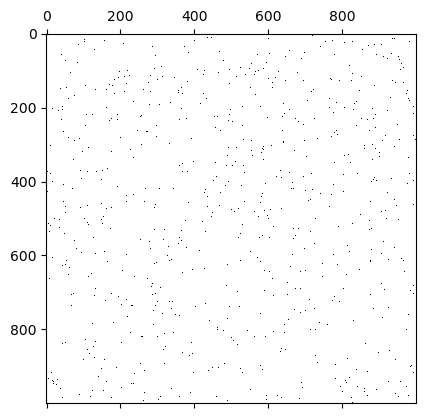

In [3]:
n = 1000
p = 5/n
A = make_sparse_matrix(n,p)
spy(A);

In [4]:
z_old = 0
z_vals = []
x = random.rand(len(A))
for i in range(10):
    z = x/norm(x,2)
    z_vals.append(z)    
    
    step_change = norm(z-z_old,inf)
    print('z change =', step_change)    
    z_old = z
        
    x = dot(A,z)
    beta = z@x

z change = 0.05411538254243187
z change = 0.07582528818018003
z change = 0.03943707500085663
z change = 0.015634514659676843
z change = 0.0069805010993351235
z change = 0.0032484621647525178
z change = 0.0015024978847140921
z change = 0.0009269983798761289
z change = 0.000361934891572456
z change = 0.00012805661844926541


In [5]:
beta

4.985146826342919

In [6]:
lams, V = eig(A)

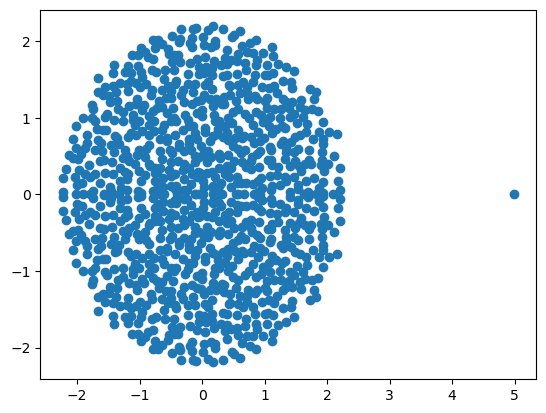

In [7]:
scatter(real(lams),imag(lams))

In [8]:
max_id = argsort(lams)[-1]
max_eval = lams[max_id]
max_eval

(4.985141958245348+0j)

/Users/danetaylor/anaconda3/lib/python3.11/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


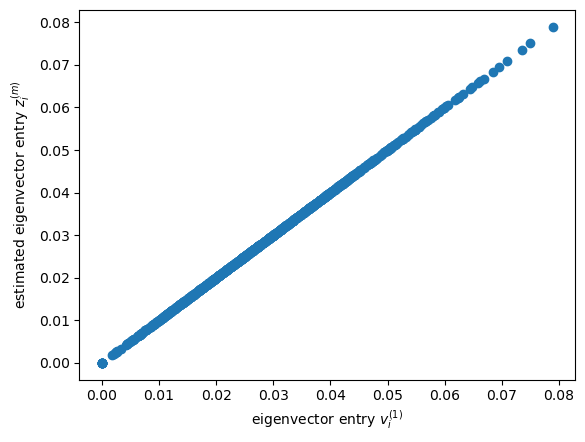

In [9]:
v_max = V[:,max_id]*sign(V[0,max_id])
scatter(v_max,z)
xlabel('eigenvector entry $v^{(1)}_i$')
ylabel('estimated eigenvector entry $z^{(m)}_i$');

## 2. Rayleigh Quotient Iteration

In [10]:
def RQI(A,x,tol=1e-14):
    I = eye(len(x))
    z_old = 0
    step_change = 10
    counter = 0
    z_vals = []
    while step_change > tol:
        z = x/norm(x,2)
        z = z*sign(z[0])
        z_vals.append(z)
        beta = z@(A@z)
        #print(beta)
                
        step_change = norm(z-z_old,inf)
        #print('z change =', step_change)    
        z_old = z
        
        MATRIX = A-beta*I
        x = linalg.solve(MATRIX,z)
                        
        counter += 1
    #z_vals = array(z_vals)

    return beta,z,counter,z_vals

In [11]:
estimated_eval2,z2,counter,z_vals = RQI(A,x0)

NameError: name 'x0' is not defined

In [ ]:
estimated_eval2

In [ ]:
scatter(v_max,z2)
xlabel('eigenvector entry $v^{(1)}_i$')
ylabel('estimated eigenvector entry $z^{(m)}_i$');

In [ ]:
TRIALS = 10
timeit.timeit('RQI(A,x0,tol)', globals=globals(),  number=TRIALS)/TRIALS

## 3. Deflation

In [ ]:
def make_sparse_matrix(n,p):    
    A = array(random.rand(n,n)<p,dtype=float)
    return A

def power_method(A,x0,tol):
    z_old = 0
    x=x0
    step_change = 10
    counter = 0
    z_vals = []
    while step_change > tol:
        z = x/norm(x,2)
        z_vals.append(z)
        
        step_change = norm(z-z_old,inf)
        #print('z change =', step_change)    
        z_old = z
        
        x = A@z
        beta = z@x
        counter += 1
    z_vals = array(z_vals)
    return beta,z,counter,z_vals

In [ ]:
A = make_sparse_matrix(n,p)
lams,V = eig(A)
scatter(real(lams),imag(lams));

In [ ]:
lam,v  =  power_method(A) #,x0,tol)
_,u  =  power_method(A.T) #,tol)

A2 = A - outer(lam*v,u)

In [ ]:
lams2,V2 = eig(A2)
scatter(real(lams2),imag(lams2))

# 4. QR Iteration yields eigenvectors

In [ ]:
A = array([[4, 3],
           [3, -3]])
evals,evecs = eig(A)
evals

In [ ]:
AA = A.copy()
QQ = eye(len(AA))
for i in range(20):
    Q,R = linalg.qr(AA)
    AA = R@Q
    QQ = QQ@Q

In [ ]:
QQ

In [ ]:
evecs

# 4. Householder Method for Computing $A=QR$

In [ ]:
Q,R = linalg.qr(A)
Q

In [ ]:
R

In [146]:
w = array([-1,3])/sqrt(10)
U = eye(2) - 2*outer(w,w)
U

array([[ 0.8,  0.6],
       [ 0.6, -0.8]])